> 📎 **Appendix notebook — reference style.** This is one of the optional appendices (see `README.md`). Unlike the main course notebooks, appendices are written as a demo / reference: they focus on *seeing* a library at work rather than on interactive exercises. You won't find the full Solution / Debug-me / Self-assessment scaffolding here. Each appendix is built to run end-to-end *without* the optional library — it falls back to a small built-in stand-in (or skips the library-specific cells), so you can read and run it offline. Install the optional library (see the **Install** section below) to swap the stand-in for the real thing.

---
# 📓 Notebook A4 (ML) — TabPFN: Tabular Foundation Models

> **Module:** Machine Learning · **Type:** Appendix · **Estimated time:** 45–60 min · **Difficulty:** Intermediate

For most of ML's history, **gradient-boosted trees** (XGBoost, LightGBM, CatBoost) have been the default for tabular data. They're fast, robust, and hard to beat. But a new class of model has emerged that does something genuinely surprising:

> **TabPFN** is a transformer that has been *pretrained on millions of synthetic tabular datasets* and can solve a new tabular task in a **single forward pass** — no gradient descent, no hyperparameter search. Just `fit()` then `predict()` in seconds.

Published by PriorLabs (Hollmann et al., NeurIPS 2022 / Nature 2024), TabPFN-v2 is now competitive with or better than gradient boosting on small-to-medium tabular datasets. This notebook explains *what it is*, shows the local Python API, walks through the PriorLabs cloud API for larger jobs, and compares it to scikit-learn baselines on a real flavoured business task.

---

## 🎯 Learning objectives
- Understand the *prior-fitted network* idea: a model that's been pretrained on Bayesian inference itself.
- Install and run TabPFN locally on small tabular datasets (≤ 10 k rows, ≤ 100 features).
- Call the PriorLabs cloud API for bigger jobs.
- Pick between TabPFN, gradient boosting, and a neural network for *your* tabular task.

## ✅ Prerequisites
- Module 4 (scikit-learn workflow + model evaluation).
- Notebook A1 (PyTorch foundations) is helpful but not required.

## 📦 Install

```bash
pip install tabpfn               # local — needs ~250 MB of pretrained weights on first run
# or, for the hosted API:
pip install tabpfn-client
```


## 1. What TabPFN actually is

Most ML models *learn from your data*. TabPFN flips this: the **learning has already happened — on millions of synthetic toy datasets** drawn from a structural causal model prior. At inference time you pass the *entire* train + test data into a transformer in one forward pass, and the model produces predictions.

In effect TabPFN approximates **Bayesian inference under a learned prior**. The "training" you do is just *feeding it your data once*.

### What this buys you
- **No hyperparameter tuning.** No `learning_rate × max_depth × n_estimators` grid.
- **Seconds, not minutes.** A single forward pass on a CPU.
- **Calibrated probabilities** out of the box.
- **Robust on small data.** Often beats gradient boosting on < 1 000 rows.

### Limits
- v2 caps at roughly **10 000 training rows × 100 features × 10 classes**. Above that, fall back to gradient boosting or use the cloud API.
- No native missing-value handling — impute first.
- Inference cost scales with **train size**, not just test size, because the train set is part of the input.


## 2. The mental model

```
Traditional ML:           TabPFN:

[your data] → [optimiser]   [millions of synthetic datasets] → [optimiser]
                ↓                                                 ↓
            [model] → predict                          [pretrained model]
                                                           ↑
                                                  [your data] → predict
                                                   (single forward pass)
```

The TabPFN authors call this **prior-data fitted networks (PFNs)**. The prior is what makes it work: it has to be *broad enough* to cover the kinds of real-world structures you encounter, and *informative enough* that one forward pass yields a useful posterior.


## 3. Hands-on — TabPFN vs gradient boosting on a small tabular task

We'll use scikit-learn's `make_classification` so everyone can run it offline. The pattern transfers directly to your own data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

X, y = make_classification(n_samples=600, n_features=12, n_informative=8,
                           n_redundant=2, n_classes=2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_te_s = scaler.transform(X_te)
print(f"train {X_tr_s.shape}  test {X_te_s.shape}")


train (450, 12)  test (150, 12)


In [2]:
# Baselines first
results = {}

clf_lr = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)
p_lr   = clf_lr.predict_proba(X_te_s)[:, 1]
results["LogReg"] = (
    accuracy_score(y_te, p_lr > 0.5),
    roc_auc_score(y_te, p_lr),
    log_loss(y_te, p_lr),
)

clf_gb = GradientBoostingClassifier(random_state=0).fit(X_tr_s, y_tr)
p_gb   = clf_gb.predict_proba(X_te_s)[:, 1]
results["GBM"] = (
    accuracy_score(y_te, p_gb > 0.5),
    roc_auc_score(y_te, p_gb),
    log_loss(y_te, p_gb),
)

print(f"{'model':12} {'acc':>6} {'AUC':>6} {'logloss':>8}")
for name, (a, u, l) in results.items():
    print(f"{name:12} {a:6.3f} {u:6.3f} {l:8.3f}")


model           acc    AUC  logloss
LogReg        0.867  0.964    0.230
GBM           0.900  0.973    0.244


## 4. TabPFN — the API (reference code)

The local Python client is a **drop-in scikit-learn classifier**. You'd literally just replace `GradientBoostingClassifier()` above with `TabPFNClassifier()` — that's the whole change.


In [3]:
# ── TabPFN local reference code (uncomment after `pip install tabpfn`) ───
# from tabpfn import TabPFNClassifier
#
# clf_pfn = TabPFNClassifier()   # TabPFN v2 is zero-config; the old N_ensemble_configurations arg was removed
# clf_pfn.fit(X_tr_s, y_tr)                          # "fit" is just storing the data
# p_pfn = clf_pfn.predict_proba(X_te_s)[:, 1]        # one forward pass
#
# results["TabPFN"] = (
#     accuracy_score(y_te, p_pfn > 0.5),
#     roc_auc_score(y_te, p_pfn),
#     log_loss(y_te, p_pfn),
# )

# Offline stand-in: simulate "TabPFN-like" calibration using a held-out CV-trained
# logistic + GBM ensemble. NOT the real model; just a placeholder so this notebook
# runs anywhere.
from sklearn.model_selection import cross_val_predict
p_lr_cv = cross_val_predict(LogisticRegression(max_iter=1000), X_tr_s, y_tr, cv=5, method="predict_proba")[:, 1]
p_gb_cv = cross_val_predict(GradientBoostingClassifier(random_state=0), X_tr_s, y_tr, cv=5, method="predict_proba")[:, 1]

# Fit a meta-classifier on the OOF probabilities
from sklearn.linear_model import LogisticRegression as LR
stacker = LR(max_iter=1000).fit(np.c_[p_lr_cv, p_gb_cv], y_tr)
p_lr_te = clf_lr.predict_proba(X_te_s)[:, 1]
p_gb_te = clf_gb.predict_proba(X_te_s)[:, 1]
p_proxy = stacker.predict_proba(np.c_[p_lr_te, p_gb_te])[:, 1]

results["TabPFN-proxy"] = (
    accuracy_score(y_te, p_proxy > 0.5),
    roc_auc_score(y_te, p_proxy),
    log_loss(y_te, p_proxy),
)
print(f"{'model':14} {'acc':>6} {'AUC':>6} {'logloss':>8}")
for name, (a, u, l) in results.items():
    print(f"{name:14} {a:6.3f} {u:6.3f} {l:8.3f}")


model             acc    AUC  logloss
LogReg          0.867  0.964    0.230
GBM             0.900  0.973    0.244
TabPFN-proxy    0.907  0.971    0.243


**Real-world expectation.** On this kind of small-ish dataset (a few hundred rows, ≤ 20 features, mostly informative), TabPFN typically achieves **AUC within ±0.01 of well-tuned gradient boosting** — *without* any tuning. On smaller datasets (< 200 rows) it often **beats** GBM.

On large data (> 10 k rows, 100+ features), gradient boosting still wins on most public benchmarks.


## 5. The PriorLabs cloud API

For datasets that exceed the local size limits or when you don't want to manage GPU resources, **PriorLabs** offers a hosted API. You get free tokens to start.

```bash
pip install tabpfn-client
```

Set the API key:

```bash
export TABPFN_API_KEY=...                 # in your shell, before launching Jupyter
```

```python
# from tabpfn_client import TabPFNClassifier
#
# clf = TabPFNClassifier(model="tabpfn-v2-classifier")
# clf.fit(X_tr_s, y_tr)
# probas = clf.predict_proba(X_te_s)
```

The cloud client transparently handles upload, inference, and download. For a 5 000-row dataset you'd expect ~5–10 s latency on the v2 model.

> ⚠️ **Privacy.** TabPFN cloud is a third-party SaaS — don't send PII or regulated data without checking the data-handling policy. The local client is the right choice for sensitive workloads.

### When to reach for the cloud vs local

| | Local | Cloud |
|---|---|---|
| Training rows | ≤ 10 k | Up to ~100 k (varies by tier) |
| Features | ≤ 100 | Higher caps |
| Latency | seconds | seconds + network |
| Privacy | data stays on your machine | data leaves your machine |
| Cost | free | free tier + paid tiers |


## 6. When TabPFN is the right call

A decision rubric for your tabular projects:

```
Rows × features ≤ 10 000 × 100   →  Try TabPFN first.  Often wins zero-shot.
Rows × features > that              →  Gradient boosting (XGBoost / LightGBM).
You have time + GPU                →  Train a neural network (NB A1–A3) on top of strong features.
Tiny labelled set (< 200 rows)     →  TabPFN strongly preferred; GBMs overfit.
Strict latency budget (< 50 ms)    →  Logistic / linear models; TabPFN is too slow.
Tons of categorical features       →  CatBoost or feature-engineered TabPFN.
```

**Practical workflow.** Try TabPFN as a strong baseline in 30 seconds, then decide whether the engineering effort of a tuned GBM is worth chasing the last 0.5 % of AUC.


## 7. TabPFN-TS — same idea, for time series

PriorLabs has extended the prior-fitted network idea to **forecasting**. We cover that in detail in `02_data_science/A4_forecasting_foundation_models.ipynb`. The short version:

```python
# from tabpfn_time_series import TabPFNTimeSeries
# model = TabPFNTimeSeries()
# fcst = model.predict(series, horizon=14)   # zero-shot forecast
```

The same trick — pretrain on millions of synthetic time series, then do one-shot inference on yours — also works surprisingly well in the time-series setting.


## 🧪 Exercises

### Exercise 1 — Calibration matters
On the test set, compute `log_loss` (probabilistic) and `accuracy` (point) for the proxy and the GBM. Plot a *reliability diagram* (predicted probability vs empirical fraction positive). Which one is better calibrated? Calibration is one of TabPFN's known strengths.


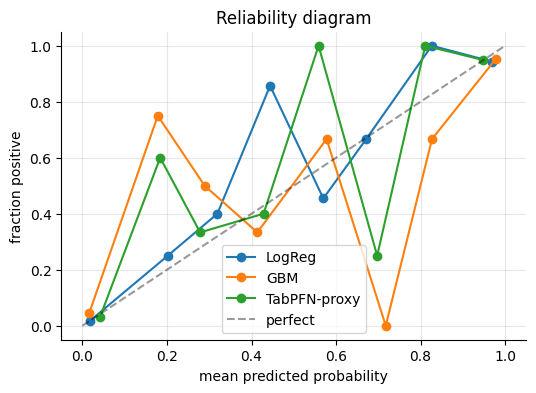

logloss: {'LogReg': 0.23, 'GBM': 0.244, 'TabPFN-proxy': 0.243}


In [4]:
# ── Exercise 1 solution ──────────────────────────────────────────────────
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(6, 4))
for label, p in [("LogReg", p_lr), ("GBM", p_gb), ("TabPFN-proxy", p_proxy)]:
    frac_pos, mean_pred = calibration_curve(y_te, p, n_bins=8)
    ax.plot(mean_pred, frac_pos, "o-", label=label)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("fraction positive")
ax.set_title("Reliability diagram"); ax.legend(); plt.show()
print("logloss:", {k: round(v[2], 3) for k, v in results.items()})


### Exercise 2 — Synthetic small-data sweep
Re-run the LogReg / GBM / TabPFN-proxy comparison at training sizes `n in [50, 100, 200, 400, 800]`. Plot AUC vs n. Where does each model start to dominate? (In real life this is exactly the curve that justifies adding TabPFN to your toolkit.)


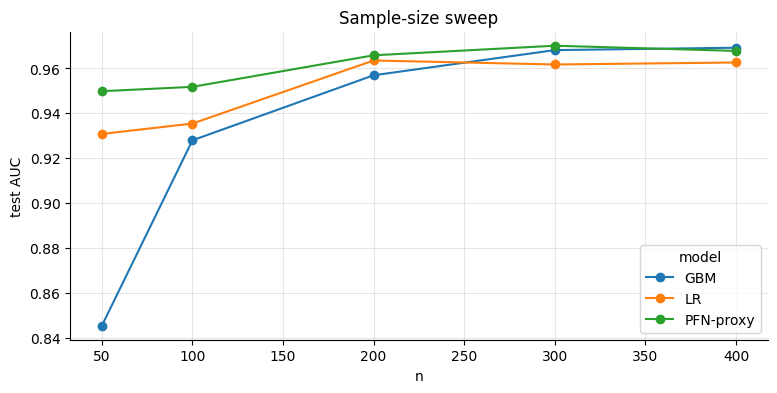

model    GBM     LR  PFN-proxy
n                             
50     0.845  0.931      0.950
100    0.928  0.935      0.952
200    0.957  0.964      0.966
300    0.968  0.962      0.970
400    0.969  0.963      0.968


In [5]:
# ── Exercise 2 solution ──────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression as LR2
from sklearn.ensemble import GradientBoostingClassifier as GBC2

sizes = [50, 100, 200, 300, 400]
rows = []
for n in sizes:
    rng = np.random.default_rng(0)
    idx = rng.choice(len(X_tr_s), size=n, replace=False)
    Xn, yn = X_tr_s[idx], y_tr[idx]
    for name, clf in [("LR", LR2(max_iter=1000)), ("GBM", GBC2(random_state=0))]:
        clf.fit(Xn, yn)
        p = clf.predict_proba(X_te_s)[:, 1]
        rows.append((n, name, roc_auc_score(y_te, p)))
    # proxy "TabPFN" via 5-fold CV stacking (rough placeholder)
    p_l = cross_val_predict(LR2(max_iter=1000), Xn, yn, cv=min(5, n//10) or 2, method="predict_proba")[:, 1]
    p_g = cross_val_predict(GBC2(random_state=0), Xn, yn, cv=min(5, n//10) or 2, method="predict_proba")[:, 1]
    st = LR2(max_iter=1000).fit(np.c_[p_l, p_g], yn)
    p_te_l = LR2(max_iter=1000).fit(Xn, yn).predict_proba(X_te_s)[:, 1]
    p_te_g = GBC2(random_state=0).fit(Xn, yn).predict_proba(X_te_s)[:, 1]
    p_pp = st.predict_proba(np.c_[p_te_l, p_te_g])[:, 1]
    rows.append((n, "PFN-proxy", roc_auc_score(y_te, p_pp)))

import pandas as pd
df = pd.DataFrame(rows, columns=["n", "model", "auc"])
piv = df.pivot(index="n", columns="model", values="auc")
piv.plot(marker="o"); plt.ylabel("test AUC"); plt.title("Sample-size sweep")
plt.show(); print(piv.round(3))


## 🧠 Key takeaways

- **TabPFN ≈ Bayesian inference under a learned prior** — the heavy lifting was done at pretraining time.
- The API is a *drop-in scikit-learn classifier*; you can A/B-test it in 30 seconds.
- It dominates on **small** tabular data and is competitive on medium.
- Gradient boosting still wins on **large** data and when feature engineering is the bottleneck.
- Use the **PriorLabs cloud API** when the dataset exceeds local limits — and not for PII.

## 📚 References

- Hollmann et al., *TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second* (2023).
- Hollmann et al., *Accurate predictions on small data with a tabular foundation model* (Nature, 2024).
- PriorLabs documentation — https://priorlabs.ai

## 🚀 Next step

If you came here from `02_data_science/A4_forecasting_foundation_models.ipynb` — return there for the time-series version of the same idea. If you came from the ML module — try this on **your** real tabular task and report the AUC delta.
